<a href="https://colab.research.google.com/github/2carol/capacitacao-pds/blob/Projeto1/PDS_projeto1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

x: [ 1.  1. -1. -1.  1.  1. -1. -1.  1.  1.]
h: [1. 1. 1. 1. 1.]

y (puro): [ 1.  2.  1.  0.  1.  1. -1. -1.  1.  1.  0.  1.  2.  1.]
y (Numpy): [ 1.  2.  1.  0.  1.  1. -1. -1.  1.  1.  0.  1.  2.  1.]
Verificando se o resultado bateu  True


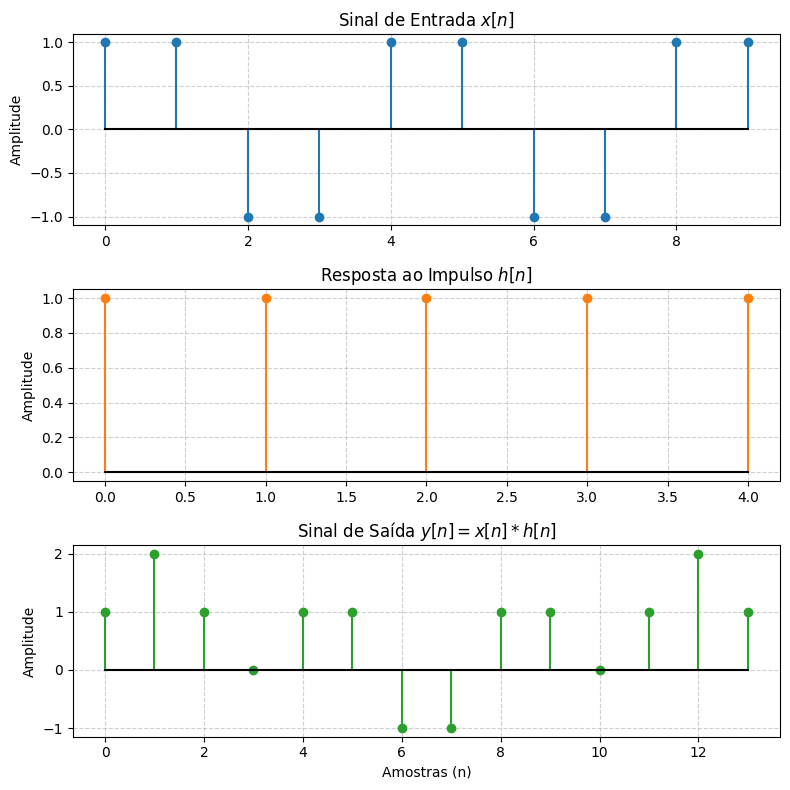


N = 500, M = 500
Python puro: 0.0546s
Numpy:       0.000101s
Numpy é 540x mais rápido


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

def convolucao_discreta(x, h):
    #convolução  simples
    x = list(x)
    h = list(h)
    N, M = len(x), len(h)
    y = [0.0] * (N + M - 1)
    for n in range(N):
        for k in range(M):
            y[n + k] += x[n] * h[k]
    return y

def gerar_sinais(N=10, n_inicio_x=0, tamanho_bloco=2, amplitude_x=1.0,
                  n_inicio_h=0, n_fim_h=4, amplitude_h=1.0):
    #sinal de entrada: alternado
    indices = np.arange(N)
    sinais = np.where((indices // tamanho_bloco) % 2 == 0, 1.0, -1.0)
    x = amplitude_x * sinais
    #resposta ao impulso: porta
    M = n_fim_h - n_inicio_h + 1
    h = np.full(M, amplitude_h, dtype=float)
    return x, n_inicio_x, h, n_inicio_h

def medir_tempo(func, *args, repeticoes=3):
    tempos = []
    for _ in range(repeticoes):
        t0 = time.perf_counter()
        func(*args)
        tempos.append(time.perf_counter() - t0)
    return sum(tempos) / len(tempos)

def plotar_sinais(x, h, y, offset_x, offset_h, offset_y):
    fig, axs = plt.subplots(3, 1, figsize=(8, 8))
    n_x = np.arange(offset_x, offset_x + len(x))
    n_h = np.arange(offset_h, offset_h + len(h))
    n_y = np.arange(offset_y, offset_y + len(y))

    axs[0].stem(n_x, x, basefmt="k-")
    axs[0].set_title('Sinal de Entrada $x[n]$')
    axs[0].set_ylabel('Amplitude')
    axs[0].grid(True, linestyle='--', alpha=0.6)

    axs[1].stem(n_h, h, linefmt='C1-', markerfmt='C1o', basefmt="k-")
    axs[1].set_title('Resposta ao Impulso $h[n]$')
    axs[1].set_ylabel('Amplitude')
    axs[1].grid(True, linestyle='--', alpha=0.6)

    axs[2].stem(n_y, y, linefmt='C2-', markerfmt='C2o', basefmt="k-")
    axs[2].set_title('Sinal de Saída $y[n] = x[n] * h[n]$')
    axs[2].set_xlabel('Amostras (n)')
    axs[2].set_ylabel('Amplitude')
    axs[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    x, offset_x, h, offset_h = gerar_sinais(N=10, tamanho_bloco=2,
                                              n_inicio_h=0, n_fim_h=4)

    print("x:", x)
    print("h:", h)

    y_manual = np.array(convolucao_discreta(x, h))
    y_numpy = np.convolve(x, h, mode="full")

    print("\ny (puro):", y_manual)
    print("y (Numpy):", y_numpy)
    print("Verificando se o resultado bateu: ", np.allclose(y_manual, y_numpy))

    offset_y = offset_x + offset_h

    plotar_sinais(x, h, y_manual, offset_x, offset_h, offset_y)

    #comparação de desempenho
    x_g, offset_xg, h_g, offset_hg = gerar_sinais(N=500, tamanho_bloco=2,
                                                     n_inicio_h=0, n_fim_h=499)

    t_puro = medir_tempo(convolucao_discreta, x_g, h_g)
    t_numpy = medir_tempo(np.convolve, x_g, h_g)

    print(f"\nN = 500, M = {len(h_g)}")
    print(f"Python puro: {t_puro:.4f}s")
    print(f"Numpy:       {t_numpy:.6f}s")
    print(f"Numpy é {t_puro / t_numpy:.0f}x mais rápido")

CONVOLUÇÃO DISCRETA COM AS VERSÕES ACELERADAS
Cupy está disponível: True
Verificando se o resultado bateu em todas as implementações:
Numba  == NumPy? True
CuPy   == NumPy? True

 COMPARAÇÃO DE DESEMPENHO ENTRE AS IMPLEMENTAÇÕES:
     N=M |  Py puro (s) |    NumPy (s) |    Numba (s) |     CuPy (s)
     200 |     0.006948 |     0.000028 |     0.000084 |     0.000544   -> mais rápido: NumPy
    1000 |     0.357841 |     0.000244 |     0.001327 |     0.000861   -> mais rápido: NumPy
    3000 |     2.166510 |     0.001832 |     0.008023 |     0.000741   -> mais rápido: CuPy

 RANKING GERAL (do mais rápido para o mais lento, somando todos os N testados):
  1º lugar: NumPy        (tempo total: 0.002104 s)
  2º lugar: CuPy         (tempo total: 0.002145 s)
  3º lugar: Numba        (tempo total: 0.009434 s)
  4º lugar: Python puro  (tempo total: 2.531298 s)

 O método mais rapido no geral foi: NumPy (cerca de 1202.9x mais rápido que o Python puro)



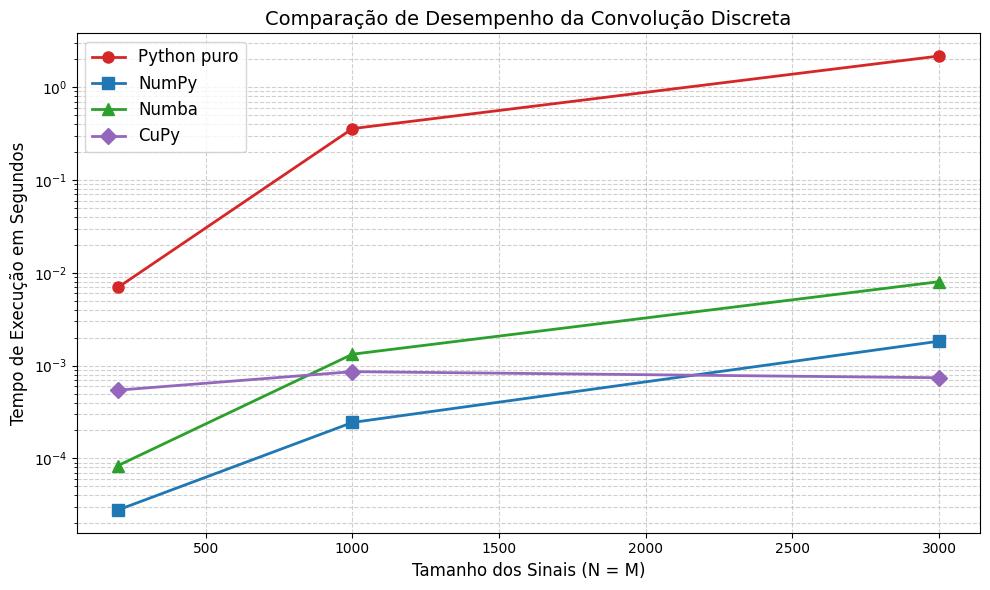

In [ ]:
from numba import njit, prange

@njit(parallel=True, cache=True)
def convolucao_numba(x, h):
    N = x.shape[0]
    M = h.shape[0]
    y = np.zeros(N + M - 1, dtype=np.float64)

    for n in prange(N):
        for k in range(M):
            y[n + k] += x[n] * h[k]
    return y

try:
    import cupy as cp
    CUPY_DISPONIVEL = True
except ImportError:
    CUPY_DISPONIVEL = False

def convolucao_cupy(x, h):
    #convolução usando cupy
    x_gpu = cp.asarray(x)
    h_gpu = cp.asarray(h)
    y_gpu = cp.convolve(x_gpu, h_gpu, mode="full")
    cp.cuda.Stream.null.synchronize()  # garante que o kernel terminou
    return cp.asnumpy(y_gpu)           # traz o resultado de volta para a CPU


def validar_corretude():
    print("Verificando se o resultado bateu em todas as implementações:")
    x, offset_x, h, offset_h = gerar_sinais(N=10, n_fim_h=5)
    y_ref = np.convolve(x, h, mode="full")
    y_ref = np.convolve(x, h, mode="full")

    y_numba = convolucao_numba(x, h)
    print(f"Numba  == NumPy? {np.allclose(y_numba, y_ref)}")

    if CUPY_DISPONIVEL:
        y_cupy = convolucao_cupy(x, h)
        print(f"CuPy   == NumPy? {np.allclose(y_cupy, y_ref)}")
    else:
        print("CuPy não disponível neste ambiente")


def comparar_desempenho():
    print("\n COMPARAÇÃO DE DESEMPENHO ENTRE AS IMPLEMENTAÇÕES:")

    tamanhos = [200, 1000, 3000]

    cabecalho = f"{'N=M':>8} | {'Py puro (s)':>12} | {'NumPy (s)':>12} | {'Numba (s)':>12}"
    if CUPY_DISPONIVEL:
        cabecalho += f" | {'CuPy (s)':>12}"
    print(cabecalho)

    x0, offset_x0, h0, offset_h0 = gerar_sinais(N=10, n_fim_h=9)
    convolucao_numba(x0, h0)

    if CUPY_DISPONIVEL:
        convolucao_cupy(x0, h0)

    #guarda os tempos de cada tamanho para depois calcular o vencedor
    tempos_por_metodo = {"Python puro": [], "NumPy": [], "Numba": []}
    if CUPY_DISPONIVEL:
        tempos_por_metodo["CuPy"] = []

    for tam in tamanhos:
        x, offset_x, h, offset_h = gerar_sinais(N=tam, n_fim_h=tam - 1)

        t_puro = medir_tempo(convolucao_discreta, x, h, repeticoes=3)
        t_numpy = medir_tempo(np.convolve, x, h, repeticoes=3)
        t_numba = medir_tempo(convolucao_numba, x, h, repeticoes=5)

        tempos_por_metodo["Python puro"].append(t_puro)
        tempos_por_metodo["NumPy"].append(t_numpy)
        tempos_por_metodo["Numba"].append(t_numba)

        tempos_desta_linha = {"Python puro": t_puro, "NumPy": t_numpy, "Numba": t_numba}

        linha = f"{tam:>8} | {t_puro:>12.6f} | {t_numpy:>12.6f} | {t_numba:>12.6f}"

        if CUPY_DISPONIVEL:
            t_cupy = medir_tempo(convolucao_cupy, x, h, repeticoes=5)
            tempos_por_metodo["CuPy"].append(t_cupy)
            tempos_desta_linha["CuPy"] = t_cupy
            linha += f" | {t_cupy:>12.6f}"

        vencedor_linha = min(tempos_desta_linha, key=tempos_desta_linha.get)
        linha += f"   -> mais rápido: {vencedor_linha}"
        print(linha)

    #ranking final: soma dos tempos de cada método em todos os tamanhos testados
    tempo_total_por_metodo = {
        metodo: sum(tempos) for metodo, tempos in tempos_por_metodo.items()
    }
    ranking = sorted(tempo_total_por_metodo.items(), key=lambda item: item[1])

    print("\n RANKING GERAL (do mais rápido para o mais lento, somando todos os N testados):")
    for posicao, (metodo, tempo_total) in enumerate(ranking, start=1):
        print(f"  {posicao}º lugar: {metodo:<12} (tempo total: {tempo_total:.6f} s)")

    mais_rapido = ranking[0][0]
    mais_lento = ranking[-1][0]
    fator = tempo_total_por_metodo[mais_lento] / tempo_total_por_metodo[mais_rapido]
    print(
        f"\n O método mais rapido no geral foi: {mais_rapido} "
        f"(cerca de {fator:.1f}x mais rápido que o {mais_lento})\n"
    )

    return tamanhos, tempos_por_metodo

import matplotlib.pyplot as plt

def plotar_desempenho(tamanhos, tempos_por_metodo):
    plt.figure(figsize=(10, 6))

    marcadores = ['o', 's', '^', 'D']
    cores = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']

    for i, (metodo, tempos) in enumerate(tempos_por_metodo.items()):
        plt.plot(tamanhos, tempos, marker=marcadores[i], color=cores[i], label=metodo, linewidth=2, markersize=8)

    plt.title("Comparação de Desempenho da Convolução Discreta", fontsize=14)
    plt.xlabel("Tamanho dos Sinais (N = M)", fontsize=12)
    plt.ylabel("Tempo de Execução em Segundos", fontsize=12)
    plt.yscale("log")

    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

def main():
    print("CONVOLUÇÃO DISCRETA COM AS VERSÕES ACELERADAS")
    print(f"Cupy está disponível: {CUPY_DISPONIVEL}")

    validar_corretude()

    # Captura os dados retornados pela comparação
    tamanhos, tempos = comparar_desempenho()

    # Plota o gráfico
    plotar_desempenho(tamanhos, tempos)

if __name__ == "__main__":
    main()